In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
import torch
from torch_geometric.data import Data
print(os.getpid())

3059050


In [2]:
def sinusoidal_positional_encoding(N, d_model):
    pe = torch.zeros(N, d_model)
    position = torch.arange(0, N, dtype=torch.float).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe  # shape [N, d_model]

In [3]:
folder_path = "Data"

sequence=[]
distance_map=[]
dca=[]
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence.append(loaded['sequence'])
        distance_map.append(loaded['distance_map'])
        dca.append(loaded['dca'])

In [4]:
def contact_from_distance(distance_map, threshold=8.0):
    contact_map = (distance_map < threshold).astype(int)
    return contact_map  


def top_k_mask(matrix, k):
    n = matrix.shape[0]

    # Get upper triangle indices (excluding diagonal)
    triu_indices = np.triu_indices(n, k=1)

    # Extract corresponding values
    values = matrix[triu_indices]

    # Get indices of top-k values
    top_k_idx = np.argpartition(values, -k)[-k:]

    # Create empty mask
    mask = np.zeros_like(matrix, dtype=int)

    # Map back to matrix indices
    rows = triu_indices[0][top_k_idx]
    cols = triu_indices[1][top_k_idx]

    # Set both (i,j) and (j,i) = 1 (since symmetric)
    mask[rows, cols] = 1
    mask[cols, rows] = 1

    return mask

In [5]:
stats=np.zeros((300,3))


for i in range(len(sequence)):
    seq=sequence[i]
    dist=distance_map[i]
    dca_map=dca[i]

    contact_map = contact_from_distance(dist, threshold=8.0)
    isfinite = np.isfinite(dist)

    k = 5*len(seq)  
    binary_map = top_k_mask(dca_map, k)

    n = binary_map.shape[0]

    for i in range(n):
        for j in range(i+1, n):  # upper triangle only

            if isfinite[i][j]:

                d = int(dist[i, j])
                stats[d, 2] += 1  # total pairs at distance d

                if binary_map[i, j]==1:

                    if contact_map[i, j]==1:
                        #true positives
                        stats[d, 0] += 1

                    elif contact_map[i, j]==0:
                        #false positives
                        stats[d, 1] += 1
tp = stats[:, 0]
fp = stats[:, 1]
total_seen = stats[:, 2]
distances = np.arange(len(stats))
total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)

/tmp/ipykernel_3059050/2004208958.py:38: RuntimeWarning: invalid value encountered in divide
  total_percentage = np.where(total_seen > 0, (tp + fp)/ total_seen , 0)
/tmp/ipykernel_3059050/2004208958.py:39: RuntimeWarning: invalid value encountered in divide
  precision = np.where((tp + fp) > 0, tp / (tp + fp), 0)


In [6]:
def sample_noisy_contact_map_from_distance(
    distance_map,
    p_detect_by_r,
    K,
    threshold=8.0,
    seed=None,
):
    """
    Generate a noisy contact map using detection probabilities vs real distance.

    Parameters
    ----------
    distance_map : (L, L) array
        Real-valued distance matrix.
    p_detect_by_r : array-like
        p_detect_by_r[r] = probability of predicting a contact at distance r
        (r is assumed to be int(distance)).
    K : int
        Total number of predicted contacts
    threshold : float
        Distance threshold separating true (<= threshold) and false (> threshold).
    seed : int or None

    Returns
    -------
    new_map : (L, L) int8 array
    stats : dict
        Contains counts of true/false contacts.
    """
    rng = np.random.default_rng(seed)

    D = np.asarray(distance_map)
    L = D.shape[0]

    # --- consider only upper triangle (i < j)
    i, j = np.triu_indices(L, k=1)

    dvals = D[i, j]
    valid = np.isfinite(dvals)

    i = i[valid]
    j = j[valid]
    dvals = dvals[valid]

    # --- convert distances to integer bins
    r = np.floor(dvals).astype(int)
    r = np.clip(r, 0, len(p_detect_by_r) - 1)

    # --- weights from empirical detection probability
    w = p_detect_by_r[r].astype(float)

    # avoid degenerate case
    if np.all(w == 0):
        raise ValueError("All detection probabilities are zero.")

    # --- split into true / false according to threshold
    true_mask = dvals <= threshold
    false_mask = dvals > threshold

    # weights per group
    w_true = w[true_mask]
    w_false = w[false_mask]

    # --- total weight
    W_true = w_true.sum()
    W_false = w_false.sum()
    W_total = W_true + W_false

    if W_total == 0:
        raise ValueError("Total weight is zero.")

    # --- allocate number of contacts
    K_true = int(round(K * W_true / W_total))
    K_false = K - K_true

    # --- indices
    true_i, true_j = i[true_mask], j[true_mask]
    false_i, false_j = i[false_mask], j[false_mask]

    # --- safety checks
    K_true = min(K_true, len(true_i))
    K_false = min(K_false, len(false_i))

    # --- probabilities within each group
    if len(w_true) > 0:
        p_true = w_true / w_true.sum()
        idx_true = rng.choice(len(true_i), size=K_true, replace=False, p=p_true)
    else:
        idx_true = np.array([], dtype=int)

    if len(w_false) > 0:
        p_false = w_false / w_false.sum()
        idx_false = rng.choice(len(false_i), size=K_false, replace=False, p=p_false)
    else:
        idx_false = np.array([], dtype=int)

    # --- build output map
    new_map = np.zeros((L, L), dtype=np.int8)

    # true contacts
    ti = true_i[idx_true]
    tj = true_j[idx_true]
    new_map[ti, tj] = 1
    new_map[tj, ti] = 1

    # false contacts
    fi = false_i[idx_false]
    fj = false_j[idx_false]
    new_map[fi, fj] = 1
    new_map[fj, fi] = 1

    stats = {
        "K_total": K,
        "K_true": len(idx_true),
        "K_false": len(idx_false),
        "fraction_true": len(idx_true) / K if K > 0 else 0.0,
    }

    return new_map, stats

In [7]:
import numpy as np
import torch
from torch_geometric.data import Data

def build_graph_contact(noisy_contact_map, distance_map=None, sep_min=5):
    
    N = len(noisy_contact_map)

    # contact map to tensor
    noisy_contact_map = torch.tensor(noisy_contact_map, dtype=torch.float)

    idx = torch.arange(N)
    i, j = torch.meshgrid(idx, idx, indexing='ij')  # shape [N, N]

    # masks
    not_self = i != j
    pair_mask = i < j
    long_range_ok = (torch.abs(i - j) >= sep_min)

    if distance_map is not None:
        known = np.isfinite(distance_map)
        known = torch.tensor(known, dtype=torch.bool)
        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        true_contact_map = torch.tensor(true_contact_map, dtype=torch.float)
        labels = (known & (true_contact_map == 1)).float()
    else:
        known = torch.ones((N, N), dtype=torch.bool)
        labels = torch.zeros((N, N), dtype=torch.float)

    edge_mask = known & long_range_ok
     # remove i == j
    valid = not_self

    src = i[valid]
    dst = j[valid]

    edge_index = torch.stack([src, dst], dim=0)
    edge_attr = noisy_contact_map[valid].unsqueeze(-1)
    y = labels[valid].unsqueeze(-1) 
        
    mask = edge_mask[valid]
    pair_mask = pair_mask[valid]

    x = sinusoidal_positional_encoding(N, d_model=16)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y,                 # binary contact labels
        edge_mask=mask,      # valid + long-range
        pair_mask=pair_mask, # only one direction per pair
        L=N
    )

In [8]:
import sequenceHandler  
import importlib
importlib.reload(sequenceHandler)
from sequenceHandler import distance_map_PDB

folder_path = "PDB"
p_detect_by_r = total_percentage

all_data = []
for file in os.listdir(folder_path):
    pdb_path = os.path.join(folder_path, file)
    chain_id = "A"
    output_map_file = "None"  

    try:
        distance_map, __ = distance_map_PDB(pdb_path, chain_id, output_map_file)

        L= distance_map.shape[0]
        K = 5 * L
        noisy_contact_map, __ = sample_noisy_contact_map_from_distance(distance_map,p_detect_by_r,K,threshold=8.0,seed=1)
        data = build_graph_contact(noisy_contact_map, distance_map)
        all_data.append(data)
    except:
        print(f"Some error occurred in the sequence {file}")


torch.save(all_data, "all_data_likeDCA.pt") 

Some error occurred in the sequence PF07714.pdb
Some error occurred in the sequence PF00016.pdb
Some error occurred in the sequence PF00031.pdb
Some error occurred in the sequence PF00044.pdb
Some error occurred in the sequence PF00046.pdb
Some error occurred in the sequence PF00050.pdb
Some error occurred in the sequence PF00058.pdb
Some error occurred in the sequence PF00069.pdb
Some error occurred in the sequence PF00073.pdb
Some error occurred in the sequence PF00082.pdb
Some error occurred in the sequence PF00095.pdb
Some error occurred in the sequence PF00096.pdb
Some error occurred in the sequence PF00098.pdb
Some error occurred in the sequence PF00101.pdb
Some error occurred in the sequence PF00111.pdb
Some error occurred in the sequence PF00121.pdb
Some error occurred in the sequence PF00124.pdb
Some error occurred in the sequence PF00130.pdb
Some error occurred in the sequence PF00157.pdb
Some error occurred in the sequence PF00170.pdb
Some error occurred in the sequence PF00

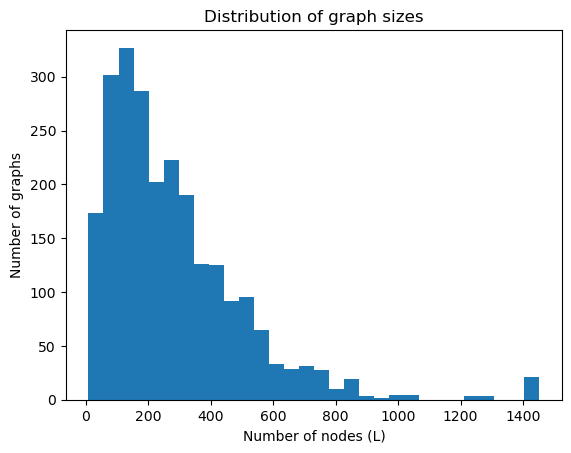

Biggest graph index: 967
Max edges: 2106852
Nodes: 1452


In [9]:

all_data = torch.load("all_data_likeDCA.pt",weights_only=False)   
import matplotlib.pyplot as plt

lengths = [data.num_nodes for data in all_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

max_edges = 0
max_idx = -1

for i, data in enumerate(all_data):
    n_edges = data.edge_index.size(1)
    if n_edges > max_edges:
        max_edges = n_edges
        max_idx = i

print("Biggest graph index:", max_idx)
print("Max edges:", max_edges)
print("Nodes:", all_data[max_idx].num_nodes)

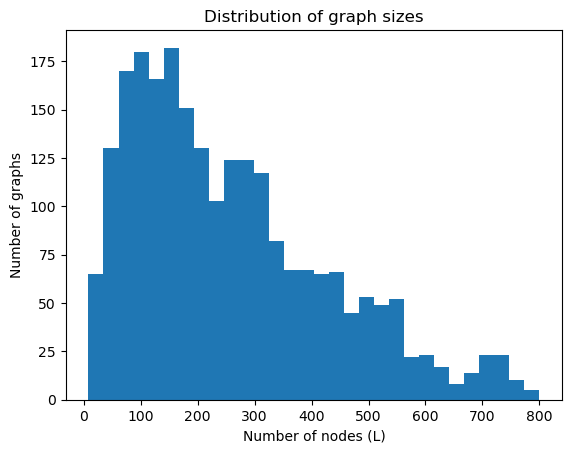

In [10]:
MAX_NODES = 800

filtered_data = [data for data in all_data if data.num_nodes <= MAX_NODES]

lengths = [data.num_nodes for data in filtered_data]

plt.figure()
plt.hist(lengths, bins=30)
plt.xlabel("Number of nodes (L)")
plt.ylabel("Number of graphs")
plt.title("Distribution of graph sizes")
plt.show()

In [11]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(filtered_data, test_size=0.2, random_state=1)


train_loader = DataLoader(train_data, batch_size=10, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

In [12]:
import torch.nn as nn
from torch_geometric.nn import MessagePassing


# MessagePassing Module    
class EdgeMessagePassingLayer(MessagePassing):

    def __init__ (self, node_in_ch, edge_in_ch, node_out_ch, edge_out_ch, aggr='mean'):
        super(EdgeMessagePassingLayer, self).__init__(aggr=aggr, flow='source_to_target')  # <---- aggregation

        #print('Relu activation')

        # Edge MLP: [e_ij, x_i, x_j] -> e'_ij
        self.lin_phi_e = nn.Sequential(
            nn.Linear(edge_in_ch + 2 * node_in_ch, edge_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(edge_out_ch, edge_out_ch)
        )

        # Node MLP: [x_i(old), agg([x_i, x_j, e'_ij] sugli edge incidenti a i)] -> x_i(new)
        self.lin_phi_x = nn.Sequential(
            nn.Linear(node_in_ch + (2 * node_in_ch + edge_out_ch),  node_out_ch),
            nn.LeakyReLU(negative_slope=0.2),
            #nn.ReLU(),
            nn.Linear(node_out_ch, node_out_ch)
        )
    
    def forward(self, x, edge_index, edge_attr):
        assert edge_attr is not None, 'Questa GNN runna solo con edge_attr!'
        
        # 1. Update edges
        edge_attr = self.edge_updater(edge_index, x=x, edge_attr=edge_attr)
        # 2. Update nodes
        x_out = self.propagate(edge_index, x=x, edge_attr=edge_attr)

        return x_out, edge_attr

    # -- EDGES --  <--- self.edge_updater
    def edge_update(self, x_i, x_j, edge_attr):
        edge_attr_out = self.lin_phi_e( torch.cat([edge_attr, x_i, x_j], dim=-1) )
        return edge_attr_out
        
    # -- NODES --   <--- self.propagate
    def message(self, x_i, x_j, edge_attr):
        message = torch.cat([x_i, x_j, edge_attr], dim=-1)
        return message

    # ... aggregate con mean o add nell'init ...

    def update(self, aggr_out, x):
        aggr = torch.cat([x, aggr_out], dim=-1)
        x_out = self.lin_phi_x(aggr)
        return x_out

In [13]:
from torch_geometric.nn import LayerNorm
import torch.nn.functional as F

class EdgeGNN(nn.Module):
    def __init__(self, node_in_ch = 8, edge_in_ch = 8, hidden_ch=128, mlp_hidden_ch=64,GNN_layers=4,node_norms =True, edge_norms=True, gating=True):
        super(EdgeGNN, self).__init__() 

        self.convs = nn.ModuleList()
        self.node_norms = nn.ModuleList() if node_norms else None
        self.edge_norms = nn.ModuleList() if edge_norms else None
        self.gating = nn.ModuleList() if gating else None

        # First layer
        if self.node_norms is not None:
            self.node_norms.append(LayerNorm(node_in_ch))
        if self.edge_norms is not None:
            self.edge_norms.append(LayerNorm(edge_in_ch))
        self.convs.append(EdgeMessagePassingLayer(
            node_in_ch = node_in_ch,
            edge_in_ch = edge_in_ch,
            node_out_ch = hidden_ch,
            edge_out_ch = hidden_ch
        ))
        if self.gating is not None:
            self.gating.append(nn.Sequential(
            nn.Linear(hidden_ch, hidden_ch),
            nn.Sigmoid()
            ))

        # Layer Intermedi
        for _ in range(GNN_layers - 1):
            if self.node_norms is not None:
                self.node_norms.append(LayerNorm(hidden_ch))
            if self.edge_norms is not None:
                self.edge_norms.append(LayerNorm(hidden_ch))

            self.convs.append(EdgeMessagePassingLayer(
                node_in_ch=hidden_ch,
                edge_in_ch=hidden_ch,
                node_out_ch=hidden_ch,
                edge_out_ch=hidden_ch
            ))
            
            if self.gating is not None:
                self.gating.append(nn.Sequential(
                nn.Linear(hidden_ch, hidden_ch),
                nn.Sigmoid()
                ))


         # MLP head for edge classification
        self.edge_head = nn.Sequential(
            nn.Linear(hidden_ch, mlp_hidden_ch),
            nn.ReLU(),
            nn.Linear(mlp_hidden_ch, 1)   # one logit
        )


    def forward(self, graph):
        x, edge_index, edge_attr, batch = graph.x, graph.edge_index, graph.edge_attr, graph.batch

        edge_batch = batch[edge_index[0]]  # batch degli edge = batch del nodo sorgente

        for i, (node_norm, edge_norm, conv) in enumerate(zip(self.node_norms, self.edge_norms, self.convs)):
            x_in = x
            e_in = edge_attr

            x = node_norm(x, batch) if node_norm is not None else x
            edge_attr = edge_norm(edge_attr, edge_batch) if edge_norm is not None else edge_attr

            x, edge_attr = conv(x, edge_index, edge_attr)

            if x_in.shape == x.shape:
                x = x + x_in

            if e_in.shape == edge_attr.shape:
                gate = self.gating[i](edge_attr) if self.gating is not None else 1.0
                edge_attr = edge_attr * gate  # edge gating
                edge_attr = edge_attr + e_in

            x = F.leaky_relu(x, negative_slope=0.2)
            edge_attr = F.leaky_relu(edge_attr, negative_slope=0.2)

        # Final projection to output space
        edge_attr = self.edge_head(edge_attr)

        return x, edge_attr

In [14]:
def compute_pos_weight(loader, device):
    total_pos = 0
    total_neg = 0

    for batch in loader:
        batch = batch.to(device)

        y = batch.y.squeeze(-1)
        mask = batch.edge_mask #& batch.pair_mask  

        y = y[mask]

        total_pos += (y == 1).sum().item()
        total_neg += (y == 0).sum().item()

    pos_weight = total_neg / max(total_pos, 1)
    return torch.tensor(pos_weight, dtype=torch.float, device=device)

In [15]:
def average_loss(model, loader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_edges = 0
    total_batches= 0

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            _, pred_logits = model(batch)
            pred_logits = pred_logits.squeeze(-1)
            true_contacts = batch.y.squeeze(-1)

            mask = batch.edge_mask #& batch.pair_mask

            loss = loss_fn(pred_logits[mask], true_contacts[mask])

            n_edges = mask.sum().item()
            total_loss += loss.item() * n_edges
            total_edges += n_edges
            total_batches += 1

    return total_loss / max(total_edges, 1)


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = EdgeGNN(node_in_ch=16, edge_in_ch=1, hidden_ch=25, mlp_hidden_ch=12, GNN_layers=3).to(device)

save_path = "best_model_cc_likeDCA.pt"
#to load an old model
# state_dict = torch.load(save_path)
# model.load_state_dict(state_dict)

pos_weight = compute_pos_weight(train_loader, device)
print("pos_weight:", pos_weight.item())
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight,reduction='mean')

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5, patience=5,min_lr=1e-6,verbose=True)


train_losses = []
val_losses = []


best_val_loss = float('inf')
patience = 10
epochs_no_improve = 0

for epoch in range(300):

    model.train()

    total_loss = 0.0
    total_edges = 0
    for batch in train_loader:

        batch = batch.to(device)
        optimizer.zero_grad()

        _, pred_logits = model(batch)

        pred_logits = pred_logits.squeeze(-1)
        true_contacts = batch.y.squeeze(-1)

        mask = batch.edge_mask #& batch.pair_mask

        loss = loss_fn(pred_logits[mask], true_contacts[mask])

        n_edges = mask.sum().item()
        total_loss += loss.item() * n_edges
        total_edges += n_edges

        loss.backward()
        optimizer.step()

    train_loss = total_loss / max(total_edges, 1)
    val_loss = average_loss(model, test_loader, loss_fn, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), save_path)

    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

pos_weight: 20.591012954711914
Epoch 0: Train Loss=0.7653, Val Loss=0.7575
Epoch 1: Train Loss=0.7644, Val Loss=0.7572
Epoch 2: Train Loss=0.7642, Val Loss=0.7581
Epoch 3: Train Loss=0.7640, Val Loss=0.7583
Epoch 4: Train Loss=0.7636, Val Loss=0.7569
Epoch 5: Train Loss=0.7632, Val Loss=0.7566
Epoch 6: Train Loss=0.7629, Val Loss=0.7561
Epoch 7: Train Loss=0.7629, Val Loss=0.7595
Epoch 8: Train Loss=0.7625, Val Loss=0.7558
Epoch 9: Train Loss=0.7624, Val Loss=0.7552
Epoch 10: Train Loss=0.7625, Val Loss=0.7569
Epoch 11: Train Loss=0.7621, Val Loss=0.7563
Epoch 12: Train Loss=0.7622, Val Loss=0.7558
Epoch 13: Train Loss=0.7617, Val Loss=0.7556
Epoch 14: Train Loss=0.7621, Val Loss=0.7555
Epoch 15: Train Loss=0.7619, Val Loss=0.7548
Epoch 16: Train Loss=0.7611, Val Loss=0.7547
Epoch 17: Train Loss=0.7613, Val Loss=0.7564
Epoch 18: Train Loss=0.7611, Val Loss=0.7562
Epoch 19: Train Loss=0.7608, Val Loss=0.7546
Epoch 20: Train Loss=0.7607, Val Loss=0.7542
Epoch 21: Train Loss=0.7613, Val L

In [44]:
save_path = "best_model_cc_likeDCA.pt"
state_dict = torch.load(save_path)
model.load_state_dict(state_dict)

<All keys matched successfully>

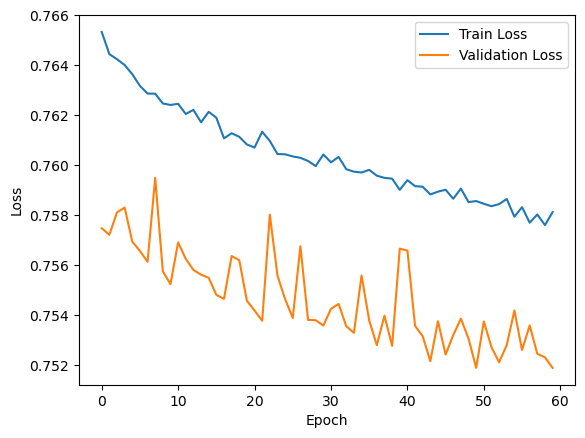

In [45]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Precision of the GNN: 0.48718489245755564
Recall of the GNN: 0.3101189576112743
F1 of the GNN: 0.37899044636459484
AUPRC of the GNN: 0.36656919807325217
Validation ROC AUC GNN: 0.8964243732129669


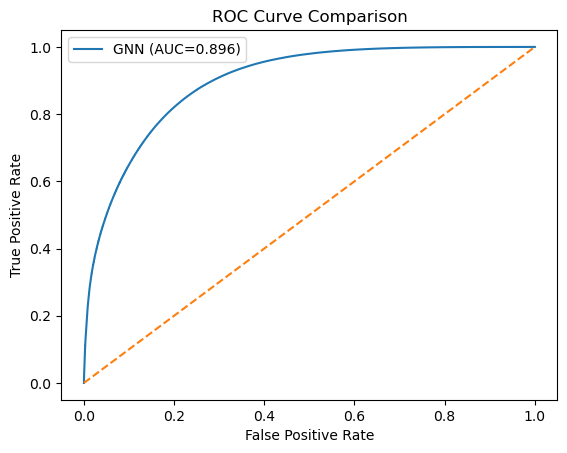

PR AUC GNN: 0.3665686489715951


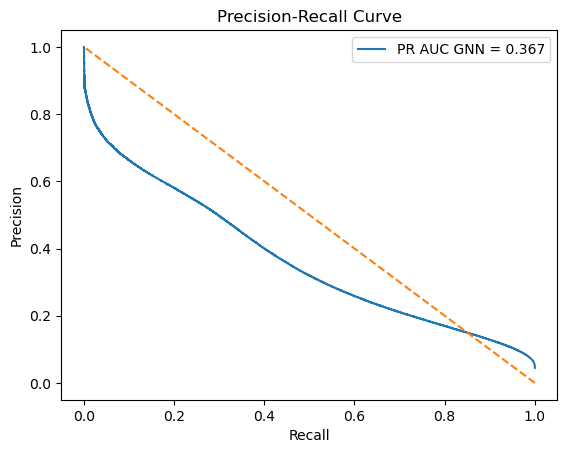

In [46]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve

model.eval()

all_probs = []
all_true = []

for batch in test_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.9

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())

print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)

print("Validation ROC AUC GNN:", roc_auc)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)


plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [58]:

def topk_L_precision(model, loader, device, ratio=1.0):
    model.eval()
    per_graph_precisions = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            _, logits = model(batch)

            probs = torch.sigmoid(logits.squeeze(-1))
            true_contacts = batch.y.squeeze(-1)

            valid_mask = batch.edge_mask & batch.pair_mask

            # graph id for each edge
            edge_graph_id = batch.batch[batch.edge_index[0]]

            num_graphs = batch.num_graphs

            for g in range(num_graphs):
                graph_mask = valid_mask & (edge_graph_id == g)

                probs_g = probs[graph_mask]
                true_g = true_contacts[graph_mask]

                if probs_g.numel() == 0:
                    continue

                # length of the protein
                L = int(batch.L[g]) if torch.is_tensor(batch.L) else int(batch.L)

                k = max(1, int(L * ratio))
                k = min(k, probs_g.numel())

                top_idx = torch.topk(probs_g, k=k).indices
                #knumber of true contacts in top-k​/k
                precision_g = (true_g[top_idx] > 0.5).float().mean().item()

                per_graph_precisions.append(precision_g)

    return float(np.mean(per_graph_precisions)), per_graph_precisions

print("Top-k*L precision:", topk_L_precision(model, test_loader, device, ratio=1)[0])

Top-k*L precision: 0.7142635047858545


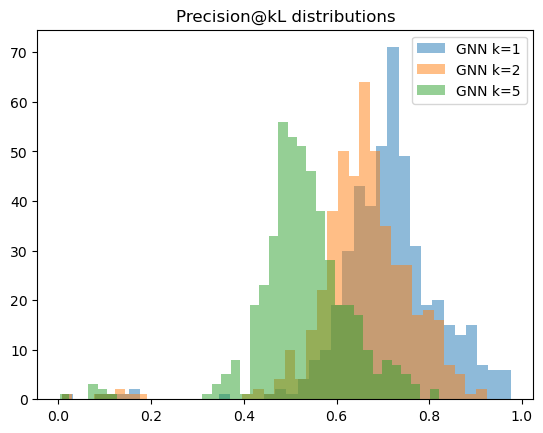

In [48]:
k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

In [49]:
k=5
precision= topk_L_precision(model, test_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

[0.4740740656852722, 0.5085299015045166, 0.07275000214576721, 0.5188191533088684, 0.5462068915367126, 0.5945945978164673, 0.4787401556968689, 0.5942029356956482, 0.5739644765853882, 0.5365750789642334, 0.4949495196342468, 0.42983052134513855, 0.47504913806915283, 0.6181818246841431, 0.4965299665927887, 0.5418604612350464, 0.5732876658439636, 0.6291999816894531, 0.5083333849906921, 0.5033942461013794, 0.6034013628959656, 0.5281081199645996, 0.48834356665611267, 0.6264317631721497, 0.4995230436325073, 0.47443944215774536, 0.6724137663841248, 0.53706294298172, 0.6615384817123413, 0.498285710811615, 0.6574074029922485, 0.5462585091590881, 0.5126984119415283, 0.5908675789833069, 0.501960813999176, 0.6720000505447388, 0.4185293912887573, 0.5575129985809326, 0.5578947067260742, 0.777011513710022, 0.5726315379142761, 0.4731707274913788, 0.701724112033844, 0.5425867438316345, 0.5210402011871338, 0.42643389105796814, 0.525795042514801, 0.8214285969734192, 0.46893206238746643, 0.6250559687614441,

In [50]:
def graph_to_matrix(data, values):
    num_nodes = data.x.shape[0]
    mat = torch.zeros((num_nodes, num_nodes))

    edge_index = data.edge_index
    mat[edge_index[0], edge_index[1]] = values.squeeze()

    return mat

Data(x=[290, 16], edge_index=[2, 83810], edge_attr=[83810, 1], y=[83810, 1], edge_mask=[83810], pair_mask=[83810], L=290)


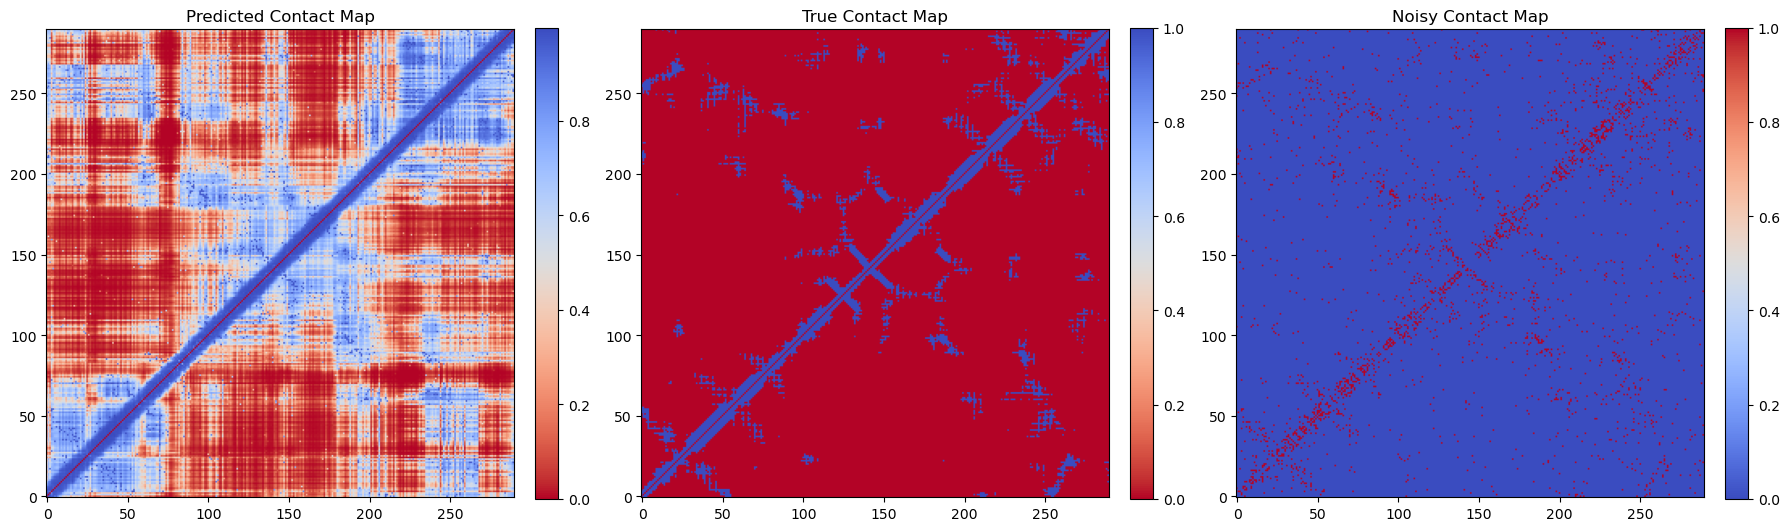

In [ ]:
    
pos=4
#worst case

i=0
with torch.no_grad():
    for batch in test_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=test_data[pos]
print(batch)



scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.8
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [52]:
###test on DCA-like data

folder_path = "Data"

dca_data = []
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        full_path = os.path.join(folder_path, file)
        
        with open(full_path, "rb") as f:
            loaded = pickle.load(f)

        sequence=loaded['sequence']
        distance_map=loaded['distance_map']
        contact_map_DCA=loaded['dca']


        k = 5*len(sequence)  
        binary_map = top_k_mask(contact_map_DCA, k)
        
        data = build_graph_contact(binary_map, distance_map)
        
        dca_data.append(data)

test_dca_loader = DataLoader(dca_data, batch_size=1, shuffle=False)

Precision of the GNN: 0.3868702296062912
Recall of the GNN: 0.32199136991807786
F1 of the GNN: 0.3514617671348937
AUPRC of the GNN: 0.27509990949223434
Validation ROC AUC GNN: 0.8046274732674362
Validation ROC AUC GNN: 0.6798060711882626


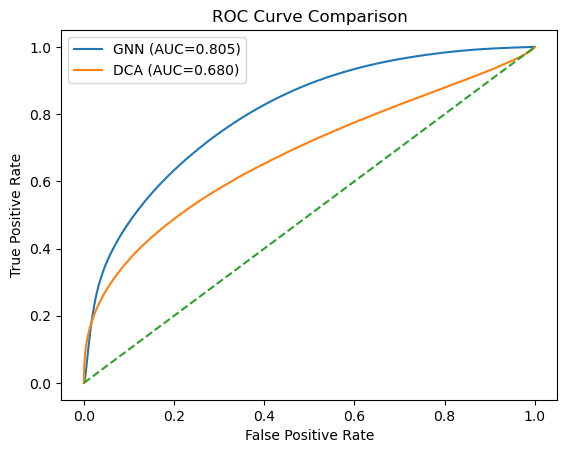

PR AUC GNN: 0.27509911557601574
PR AUC DCA: 0.26195217070831955


/home/fabio/miniconda3/envs/Internship/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


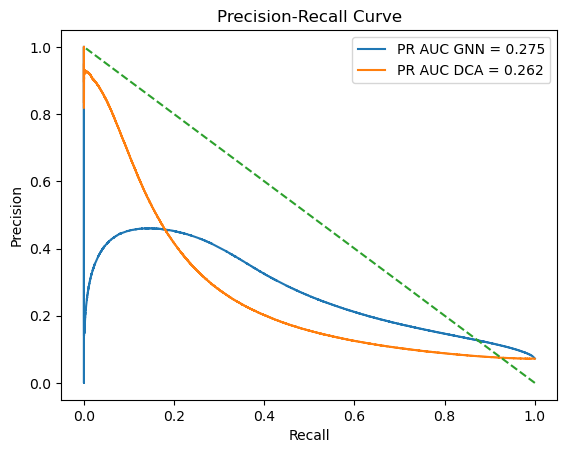

In [53]:
from sklearn.metrics import auc, precision_score, recall_score, f1_score, average_precision_score, roc_curve


all_scores = []
all_labels = []

min_sep=5
for file in os.listdir(folder_path):
    if file.endswith(".pkl"):
        with open(os.path.join(folder_path, file), "rb") as f:
            loaded = pickle.load(f)

        sequence = loaded['sequence']
        distance_map = loaded['distance_map']
        contact_map_DCA = loaded['dca']

        true_contact_map = contact_from_distance(distance_map, threshold=8.0)
        
        L = len(sequence)
        i, j = np.indices((L, L))

        mask = (np.isfinite(distance_map) & (np.abs(i - j) >= min_sep) & (i < j)) 
        # Flatten
        scores = contact_map_DCA[mask].flatten()
        labels = true_contact_map[mask].flatten()

        all_scores.append(scores)
        all_labels.append(labels)

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)





model.eval()

all_probs = []
all_true = []

for batch in test_dca_loader:
    batch = batch.to(device)

    with torch.no_grad():
        _, pred_logits = model(batch)
        probs = torch.sigmoid(pred_logits.squeeze(-1))

    true_contacts = batch.y.squeeze(-1)
    mask = batch.edge_mask & batch.pair_mask
  


    all_probs.append(probs[mask].cpu())
    all_true.append(true_contacts[mask].cpu())

all_probs = torch.cat(all_probs)
all_true = torch.cat(all_true)


threshold=0.9

pred_contacts = (all_probs >= threshold).int().numpy()
true_contacts = all_true.int().numpy()

precision = precision_score(true_contacts, pred_contacts, zero_division=0)
recall = recall_score(true_contacts, pred_contacts, zero_division=0)
f1 = f1_score(true_contacts, pred_contacts, zero_division=0)
auprc = average_precision_score(true_contacts, all_probs.numpy())




print(f"Precision of the GNN: {np.mean(precision)}")
print(f"Recall of the GNN: {np.mean(recall)}")
print(f"F1 of the GNN: {np.mean(f1)}")
print(f"AUPRC of the GNN: {np.mean(auprc)}")



# compute ROC
fpr, tpr, _ = roc_curve(all_true, all_probs)
roc_auc = auc(fpr, tpr)


print("Validation ROC AUC GNN:", roc_auc)


fpr_dca, tpr_dca, _ = roc_curve(all_labels, all_scores)
roc_auc_dca = auc(fpr_dca, tpr_dca)


print("Validation ROC AUC GNN:", roc_auc_dca)


plt.figure()

plt.plot(fpr, tpr, label=f"GNN (AUC={roc_auc:.3f})")
plt.plot(fpr_dca, tpr_dca, label=f"DCA (AUC={roc_auc_dca:.3f})")


plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

#compute PR
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(all_true, all_probs)
pr_auc = auc(recall, precision)


print("PR AUC GNN:", pr_auc)



precision_dca, recall_dca, _ = precision_recall_curve(all_labels, all_scores)
pr_auc_dca = auc(recall_dca, precision_dca)


print("PR AUC DCA:", pr_auc_dca)

plt.figure()
plt.plot(recall, precision, label=f"PR AUC GNN = {pr_auc:.3f}")
plt.plot(recall_dca, precision_dca, label=f"PR AUC DCA = {pr_auc_dca:.3f}")
plt.plot([1, 0], [0, 1], linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [54]:
def precision_at_kL_dca_per_graph(batch, k):
    scores = batch.edge_attr.squeeze(-1)  # DCA scores
    y_true = batch.y.squeeze(-1)

    mask = batch.edge_mask & batch.pair_mask

    scores = scores[mask]
    y_true = y_true[mask]

    edge_batch = batch.batch[batch.edge_index[0]][mask]

    precisions = []

    for g in edge_batch.unique():
        g_mask = edge_batch == g

        g_scores = scores[g_mask]
        g_true = y_true[g_mask]

        L = batch.L[g].item() if isinstance(batch.L, torch.Tensor) else batch.L

        kL = int(k * L)
        kL = min(kL, g_scores.numel())

        if kL == 0:
            continue

        topk_idx = torch.topk(g_scores, kL).indices
        topk_true = g_true[topk_idx]

        precision = topk_true.float().mean().item()
        precisions.append(precision)

    return precisions

Top-k*L precision DCA: 0.4299600805987216
Top-k*L precision GNN: 0.532319785598332


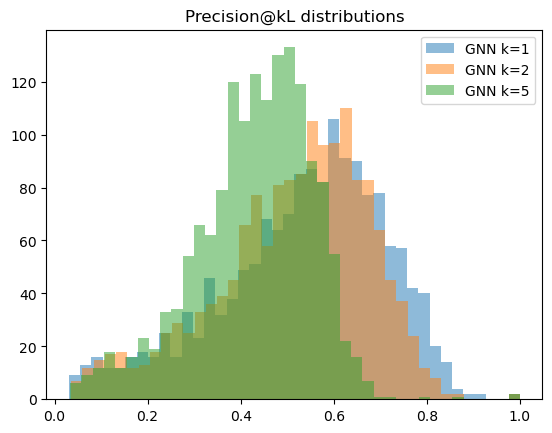

[0.43396228551864624, 0.7076923251152039, 0.6792452931404114, 0.8441558480262756, 0.5865384936332703, 0.375, 0.6000000238418579, 0.6239316463470459, 0.7956989407539368, 0.4444444477558136, 0.8198198676109314, 0.477477490901947, 0.7272727489471436, 0.7846153974533081, 0.22857144474983215, 0.6176470518112183, 0.6894824504852295, 0.6487804651260376, 0.6710526347160339, 0.545976996421814, 0.7873015999794006, 0.5853658318519592, 0.46590909361839294, 0.6904761791229248, 0.6500000357627869, 0.6455696225166321, 0.4580152630805969, 0.7092198133468628, 0.3379310369491577, 0.03316326439380646, 0.5454545021057129, 0.48148149251937866, 0.5950412750244141, 0.6808510422706604, 0.48514851927757263, 0.754054069519043, 0.6842105388641357, 0.4444444477558136, 0.604651153087616, 0.5473684668540955, 0.47441861033439636, 0.6760563254356384, 0.7060810923576355, 0.5435779690742493, 0.4969325065612793, 0.6279069781303406, 0.5757575631141663, 0.5676328539848328, 0.753398060798645, 0.6160000562667847, 0.67932486

In [60]:
k=1.0 
precision=[]
for batch in test_dca_loader:
        batch = batch.to(device)
        _, pred_logits = model(batch)
        vals= precision_at_kL_dca_per_graph(batch, k)
        precision.append(vals)


print("Top-k*L precision DCA:", np.mean(precision))
print("Top-k*L precision GNN:", topk_L_precision(model, test_dca_loader, device, ratio=k)[0])

k_values = [1,2,5]
results = {k: [] for k in k_values}
for k in k_values:
    vals= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
    results[k].extend(vals)

for k in k_values:
    plt.hist(results[k], bins=40, alpha=0.5, label=f"GNN k={k}")


plt.legend()
plt.title("Precision@kL distributions")
plt.show()

k=1
precision= topk_L_precision(model, test_dca_loader, device, ratio=k)[1]
print(precision)
print(min(precision))
print(precision.index(min(precision)))

Data(x=[104, 16], edge_index=[2, 10712], edge_attr=[10712, 1], y=[10712, 1], edge_mask=[10712], pair_mask=[10712], L=104)


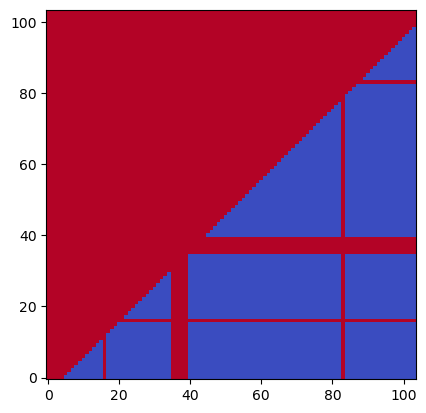

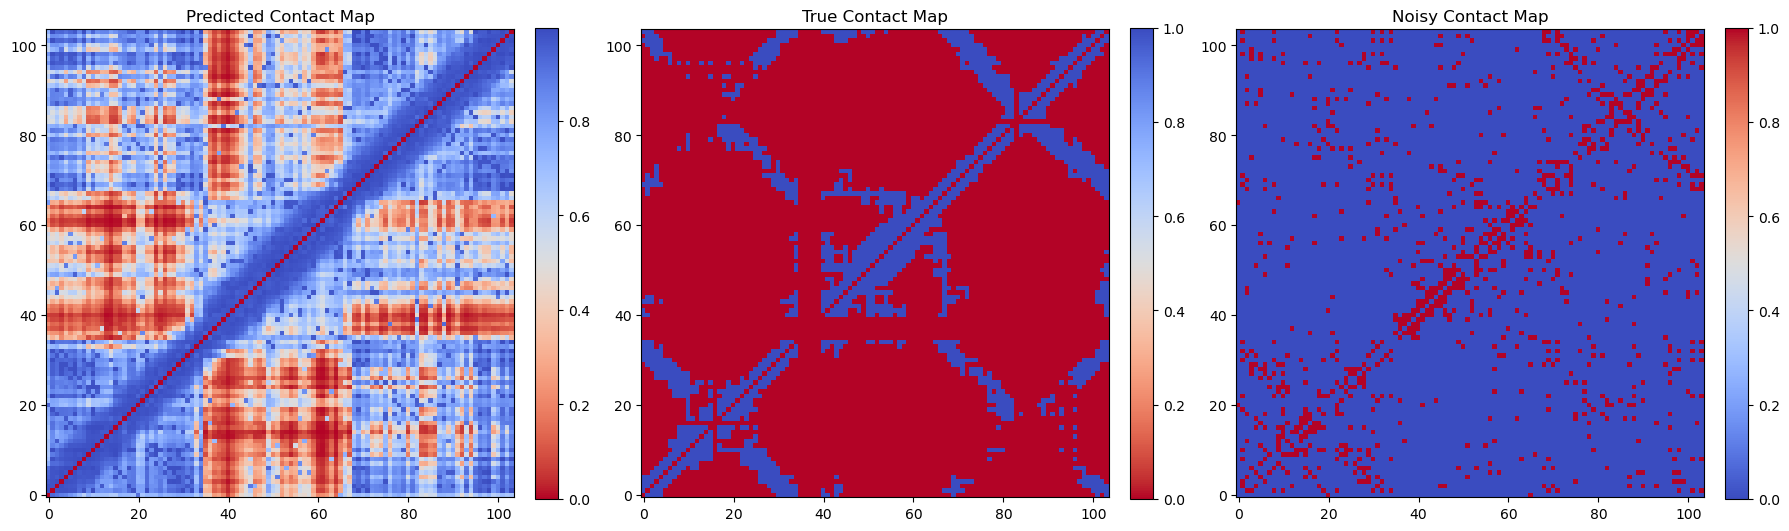

In [56]:
pos=4
#worst case

i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask
mask = batch.edge_mask & batch.pair_mask
mask = graph_to_matrix(batch, mask.squeeze(-1).cpu().float())
plt.imshow(mask, cmap='coolwarm_r', origin='lower')

scores = torch.sigmoid(pred_logits.squeeze(-1))
# threshold=0.9
# scores= (scores>= threshold).float()
pred_contact_map = graph_to_matrix(batch, scores.cpu())
true_contact_map = graph_to_matrix(batch, batch.y.cpu())
noisy_contact_map_map = graph_to_matrix(batch, batch.edge_attr.cpu())



fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# --- Predicted Distance Map ---
im0 = axes[0].imshow(pred_contact_map, cmap='coolwarm_r', origin='lower')
axes[0].set_title("Predicted Contact Map")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- True Distance Map ---
im1 = axes[1].imshow(true_contact_map, cmap='coolwarm_r', origin='lower')
axes[1].set_title("True Contact Map")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- Original Noisy Contact Map ---
im2 = axes[2].imshow(noisy_contact_map_map, cmap='coolwarm', origin='lower')
axes[2].set_title("Noisy Contact Map")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Data(x=[117, 16], edge_index=[2, 13572], edge_attr=[13572, 1], y=[13572, 1], edge_mask=[13572], pair_mask=[13572], L=117)


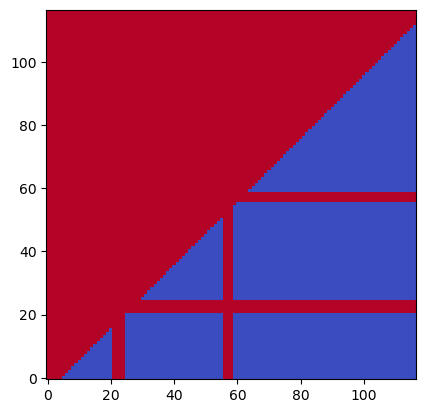

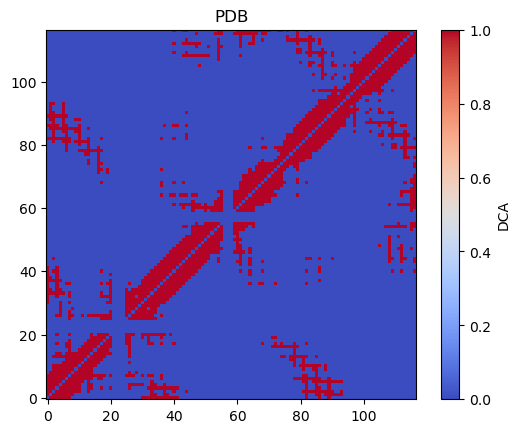

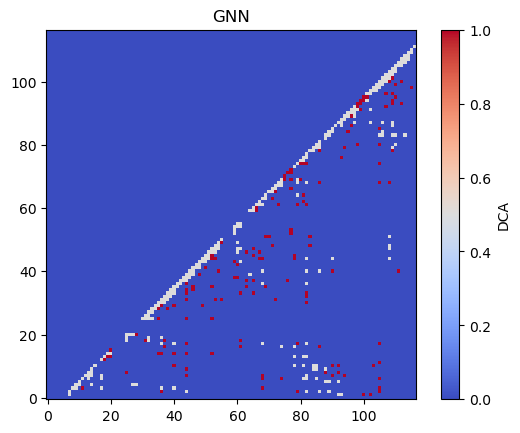

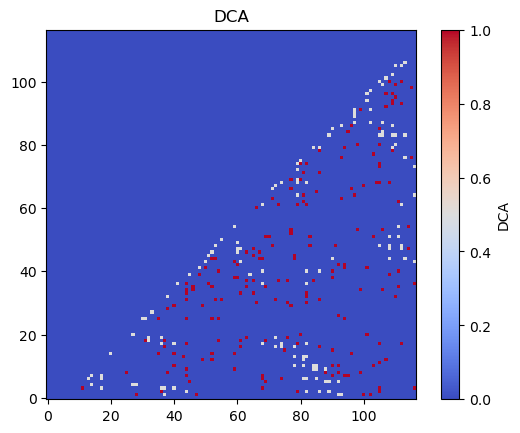

In [57]:
pos=7

#worst case

i=0
with torch.no_grad():
    for batch in test_dca_loader:
        if i==pos:
            batch = batch.to(device)
            _, pred_logits = model(batch)
        i+=1

batch=dca_data[pos]
print(batch)

mask = batch.edge_mask & batch.pair_mask
mask = batch.edge_mask & batch.pair_mask
mask = graph_to_matrix(batch, mask.squeeze(-1).cpu().float())
plt.imshow(mask, cmap='coolwarm_r', origin='lower')
L= batch.L

scores = torch.sigmoid(pred_logits.squeeze(-1))
pred_contact_map = graph_to_matrix(batch, scores.cpu())
new_map = top_k_mask(pred_contact_map, 8 * L)
contact_map = graph_to_matrix(batch, batch.y.cpu()).numpy()
noisy_contact_map = graph_to_matrix(batch, batch.edge_attr.cpu()).numpy()





plt.figure()
plt.imshow(contact_map,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("PDB")
plt.show()

true_positives = (new_map == 1) & (contact_map == 1)
false_positives = (new_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] and mask[i][j] == 1:
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and mask[i][j] == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
plt.colorbar(label="DCA")
plt.title("GNN")
plt.show()



true_positives = (noisy_contact_map == 1) & (contact_map == 1)
false_positives = (noisy_contact_map == 1) & (contact_map== 0)

true_positives = true_positives.astype(float)
false_positives = false_positives.astype(float)

result= np.zeros_like(true_positives)
for i in range(len(true_positives)):
    for j in range(len(true_positives)):
        if true_positives[i][j] == 1 and mask[i][j] == 1   :
            result[i][j] = 0.5
        elif false_positives[i][j] == 1 and mask[i][j]  == 1:
            result[i][j] = 1.0
        else:
            result[i][j] = 0.0

plt.figure()
plt.imshow(result,cmap='coolwarm', origin='lower')
#plt.imshow(false_positives,cmap='coolwarm_r', origin='lower')
plt.colorbar(label="DCA")
plt.title("DCA")
plt.show()